# Observables, correlaciones y fidelidad VQE frente a ED
Este notebook analiza los 30 VQE ya ejecutados y los compara con los estados fundamentales obtenidos por diagonalización exacta. Reconstruye cada estado VQE a partir de sus 240 parámetros y calcula magnetizaciones, correlaciones, energías y fidelidad.

In [1]:
from pathlib import Path
import json
import sys
import matplotlib.pyplot as plt
import numpy as np
NOTEBOOK_DIR = Path.cwd()
if not (NOTEBOOK_DIR / 'analyze_vqe_results.py').exists():
    NOTEBOOK_DIR = Path('Tensor Networks/ising con campo transverso').resolve()
sys.path.insert(0, str(NOTEBOOK_DIR))
from analyze_vqe_results import analyze_vqe_results
from ising_tfim_gpu import select_device
ROOT = NOTEBOOK_DIR
RESULTS_DIR = ROOT / 'results'
VQE_PATH = RESULTS_DIR / 'all_vqe_results_adam500_later150_lbfgs80.json'
if not VQE_PATH.exists():
    VQE_PATH = RESULTS_DIR / 'all_vqe_results.json'
ED_STATES_PATH = RESULTS_DIR / 'ed_ground_states.npz'
ED_METADATA_PATH = RESULTS_DIR / 'ed_ground_state_metadata.json'
ANALYSIS_PATH = RESULTS_DIR / 'vqe_ed_observables_adam500_later150_lbfgs80.json'
DEVICE = select_device(require_cuda=True)
print(f'GPU de reconstrucción: {DEVICE}')

GPU de reconstrucción: cuda


## Reconstrucción y cálculo
RUN_ANALYSIS está en False porque el análisis ya fue calculado y guardado. Si se modifican los VQE, ponerlo en True para reconstruir los 30 estados.

In [2]:
RUN_ANALYSIS = False
if RUN_ANALYSIS:
    analysis_rows = analyze_vqe_results(vqe_path=VQE_PATH, ed_state_path=ED_STATES_PATH, ed_metadata_path=ED_METADATA_PATH, output_path=ANALYSIS_PATH, device=DEVICE)
else:
    analysis_rows = json.loads(ANALYSIS_PATH.read_text(encoding='utf-8'))
    print(f'{len(analysis_rows)} filas cargadas desde {ANALYSIS_PATH}')
fields = np.asarray(sorted({row['field'] for row in analysis_rows}), dtype=float)
assert len(analysis_rows) == 30
assert all(sum(row['field'] == field for row in analysis_rows) == 3 for field in fields)
print(f'Campos: {fields}')
print('Tres VQE por campo: validado.')

30 filas cargadas desde C:\Users\the_b\Desktop\Tareas universidad\Información y Computación Cuántica\Directorios GitHub\Quantum-Computing-Personal-Projects\Tensor Networks\ising con campo transverso\results\vqe_ed_observables_adam500_later150_lbfgs80.json
Campos: [0.2 0.4 0.6 0.8 1.  1.2 1.4 1.6 1.8 2. ]
Tres VQE por campo: validado.


In [3]:
def rows_for_field(field):
    return [row for row in analysis_rows if np.isclose(row['field'], field)]
ed_energy = np.asarray([rows_for_field(field)[0]['ed_energy'] for field in fields])
vqe_energy_mean = np.asarray([np.mean([row['vqe_energy_reconstructed'] for row in rows_for_field(field)]) for field in fields])
vqe_energy_std = np.asarray([np.std([row['vqe_energy_reconstructed'] for row in rows_for_field(field)]) for field in fields])
fidelity_mean = np.asarray([np.mean([row['fidelity_with_ed'] for row in rows_for_field(field)]) for field in fields])
fidelity_std = np.asarray([np.std([row['fidelity_with_ed'] for row in rows_for_field(field)]) for field in fields])
mx_mean = np.asarray([np.mean([row['vqe']['M_x'] for row in rows_for_field(field)]) for field in fields])
mz_mean = np.asarray([np.mean([row['vqe']['M_z'] for row in rows_for_field(field)]) for field in fields])
abs_mz_mean = np.asarray([np.mean([row['vqe']['abs_M_z'] for row in rows_for_field(field)]) for field in fields])
mz2_mean = np.asarray([np.mean([row['vqe']['M_z_squared'] for row in rows_for_field(field)]) for field in fields])
nearest_zz_mean = np.asarray([np.mean([row['vqe']['mean_ZZ_nearest'] for row in rows_for_field(field)]) for field in fields])
parity_vqe_mean = np.asarray([np.mean([row['vqe']['parity_X'] for row in rows_for_field(field)]) for field in fields])
parity_vqe_std = np.asarray([np.std([row['vqe']['parity_X'] for row in rows_for_field(field)]) for field in fields])
parity_ed = np.asarray([rows_for_field(field)[0]['ed']['parity_X'] for field in fields])
parity_plus_weight_mean = np.asarray([np.mean([row['vqe']['parity_plus_weight'] for row in rows_for_field(field)]) for field in fields])
ed_even_weight_mean = np.asarray([np.mean([row['ed_even_projection_weight'] for row in rows_for_field(field)]) for field in fields])
fidelity_even_ed_mean = np.asarray([np.mean([row['fidelity_with_even_ed_reference'] for row in rows_for_field(field)]) for field in fields])
projected_fidelity_mean = np.asarray([np.mean([row['fidelity_after_even_projection'] for row in rows_for_field(field)]) for field in fields])
projected_fidelity_std = np.asarray([np.std([row['fidelity_after_even_projection'] for row in rows_for_field(field)]) for field in fields])
energy_error_mean = np.asarray([np.mean([row['absolute_energy_error_vs_ed'] for row in rows_for_field(field)]) for field in fields])
print('Resumen preparado: energía, Mx, Mz, |Mz|, Mz², ZZ vecino y fidelidad.')

Resumen preparado: energía, Mx, Mz, |Mz|, Mz², ZZ vecino y fidelidad.


## Energía y fidelidad respecto a ED

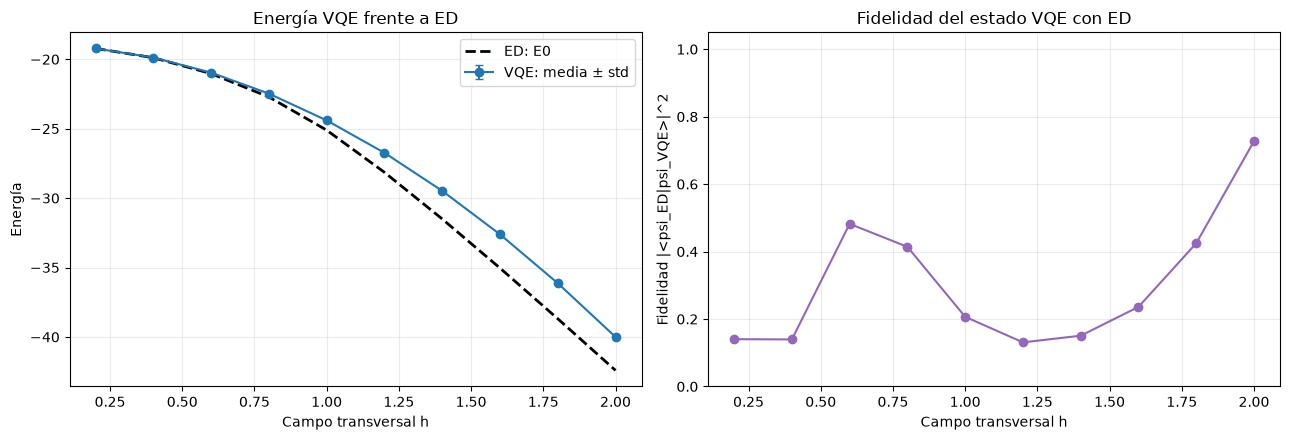

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(fields, ed_energy, 'k--', linewidth=2, label='ED: E0')
axes[0].errorbar(fields, vqe_energy_mean, yerr=vqe_energy_std, fmt='o-', capsize=3, label='VQE: media ± std')
axes[0].set_xlabel('Campo transversal h')
axes[0].set_ylabel('Energía')
axes[0].set_title('Energía VQE frente a ED')
axes[0].grid(alpha=0.25)
axes[0].legend()
axes[1].errorbar(fields, fidelity_mean, yerr=fidelity_std, fmt='o-', capsize=3, color='tab:purple')
axes[1].set_xlabel('Campo transversal h')
axes[1].set_ylabel('Fidelidad |<psi_ED|psi_VQE>|^2')
axes[1].set_ylim(0, 1.05)
axes[1].set_title('Fidelidad del estado VQE con ED')
axes[1].grid(alpha=0.25)
fig.tight_layout()
fig.savefig(RESULTS_DIR / 'vqe_energy_and_fidelity_adam500_later150_lbfgs80.png', dpi=180)
plt.show()

## Magnetizaciones y correlación ZZ de vecinos

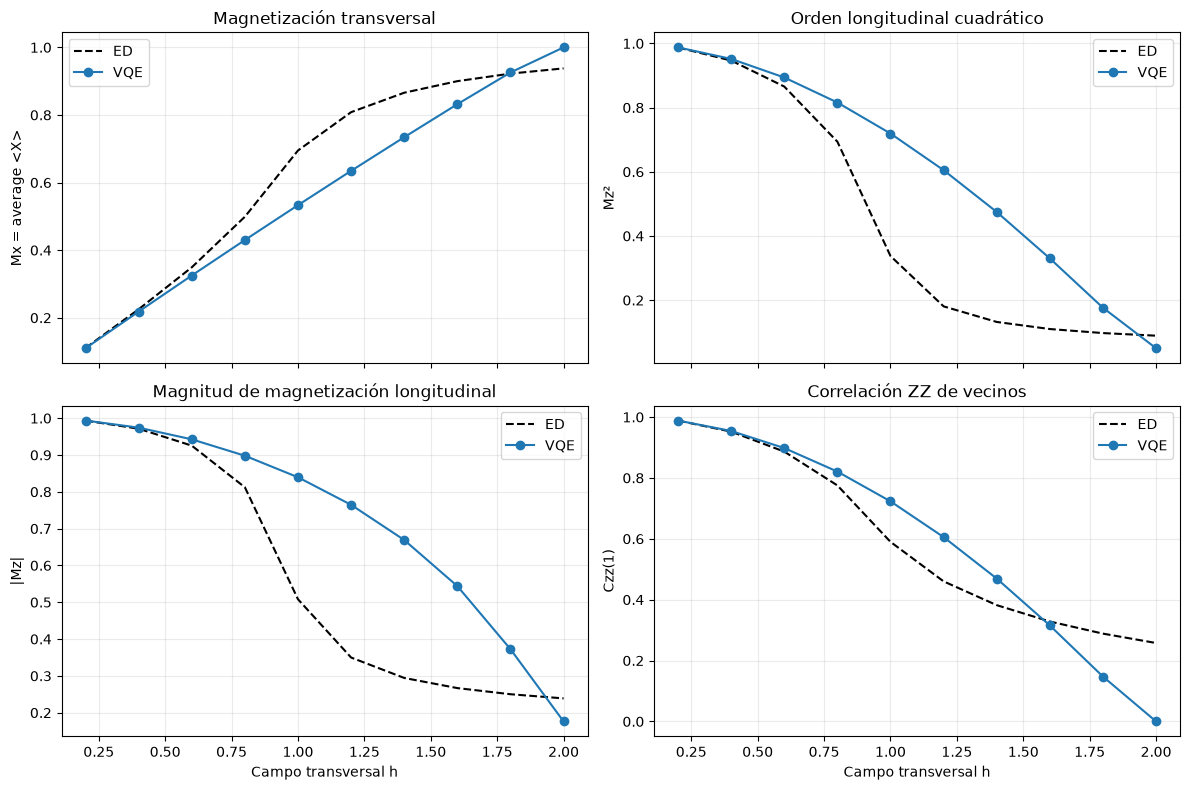

In [5]:
ed_mx = np.asarray([rows_for_field(field)[0]['ed']['M_x'] for field in fields])
ed_mz2 = np.asarray([rows_for_field(field)[0]['ed']['M_z_squared'] for field in fields])
ed_abs_mz = np.asarray([rows_for_field(field)[0]['ed']['abs_M_z'] for field in fields])
ed_nearest_zz = np.asarray([rows_for_field(field)[0]['ed']['mean_ZZ_nearest'] for field in fields])
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
axes[0, 0].plot(fields, ed_mx, 'k--', label='ED')
axes[0, 0].plot(fields, mx_mean, 'o-', label='VQE')
axes[0, 0].set_ylabel('Mx = average <X>')
axes[0, 0].set_title('Magnetización transversal')
axes[0, 1].plot(fields, ed_mz2, 'k--', label='ED')
axes[0, 1].plot(fields, mz2_mean, 'o-', label='VQE')
axes[0, 1].set_ylabel('Mz²')
axes[0, 1].set_title('Orden longitudinal cuadrático')
axes[1, 0].plot(fields, ed_abs_mz, 'k--', label='ED')
axes[1, 0].plot(fields, abs_mz_mean, 'o-', label='VQE')
axes[1, 0].set_xlabel('Campo transversal h')
axes[1, 0].set_ylabel('|Mz|')
axes[1, 0].set_title('Magnitud de magnetización longitudinal')
axes[1, 1].plot(fields, ed_nearest_zz, 'k--', label='ED')
axes[1, 1].plot(fields, nearest_zz_mean, 'o-', label='VQE')
axes[1, 1].set_xlabel('Campo transversal h')
axes[1, 1].set_ylabel('Czz(1)')
axes[1, 1].set_title('Correlación ZZ de vecinos')
for axis in axes.flat:
    axis.grid(alpha=0.25)
    axis.legend()
fig.tight_layout()
fig.savefig(RESULTS_DIR / 'vqe_magnetizations_and_zz_adam500_later150_lbfgs80.png', dpi=180)
plt.show()

## Correlación longitudinal a distancia r
Se muestran Czz(r) = promedio_i <Z_i Z_(i+r)> y la versión conectada para tres campos representativos.

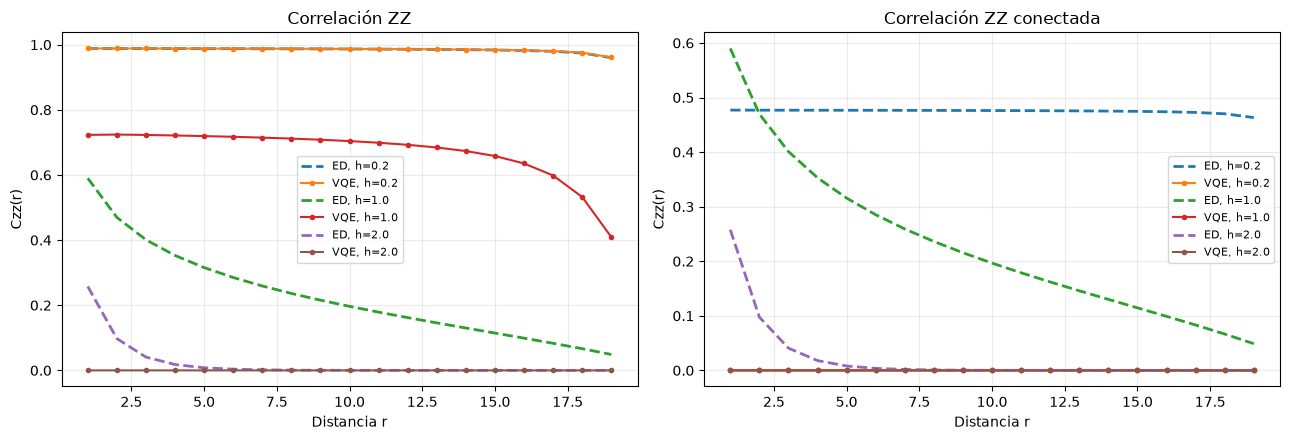

In [6]:
selected_fields = [0.2, 1.0, 2.0]
distances = np.arange(1, 20)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for field in selected_fields:
    field_rows = rows_for_field(field)
    vqe_corr = np.asarray([row['vqe']['zz_correlation_by_distance'] for row in field_rows])[:, 1:]
    ed_corr = np.asarray(field_rows[0]['ed']['zz_correlation_by_distance'])[1:]
    axes[0].plot(distances, ed_corr, '--', linewidth=2, label=f'ED, h={field:.1f}')
    axes[0].plot(distances, vqe_corr.mean(axis=0), 'o-', markersize=3, label=f'VQE, h={field:.1f}')
    vqe_connected = np.asarray([row['vqe']['connected_zz_by_distance'] for row in field_rows])[:, 1:]
    ed_connected = np.asarray(field_rows[0]['ed']['connected_zz_by_distance'])[1:]
    axes[1].plot(distances, ed_connected, '--', linewidth=2, label=f'ED, h={field:.1f}')
    axes[1].plot(distances, vqe_connected.mean(axis=0), 'o-', markersize=3, label=f'VQE, h={field:.1f}')
axes[0].set_title('Correlación ZZ')
axes[1].set_title('Correlación ZZ conectada')
for axis in axes:
    axis.set_xlabel('Distancia r')
    axis.set_ylabel('Czz(r)')
    axis.grid(alpha=0.25)
    axis.legend(fontsize=8)
fig.tight_layout()
fig.savefig(RESULTS_DIR / 'vqe_zz_correlations_by_distance_adam500_later150_lbfgs80.png', dpi=180)
plt.show()

## Paridad global y proyeccion al sector par

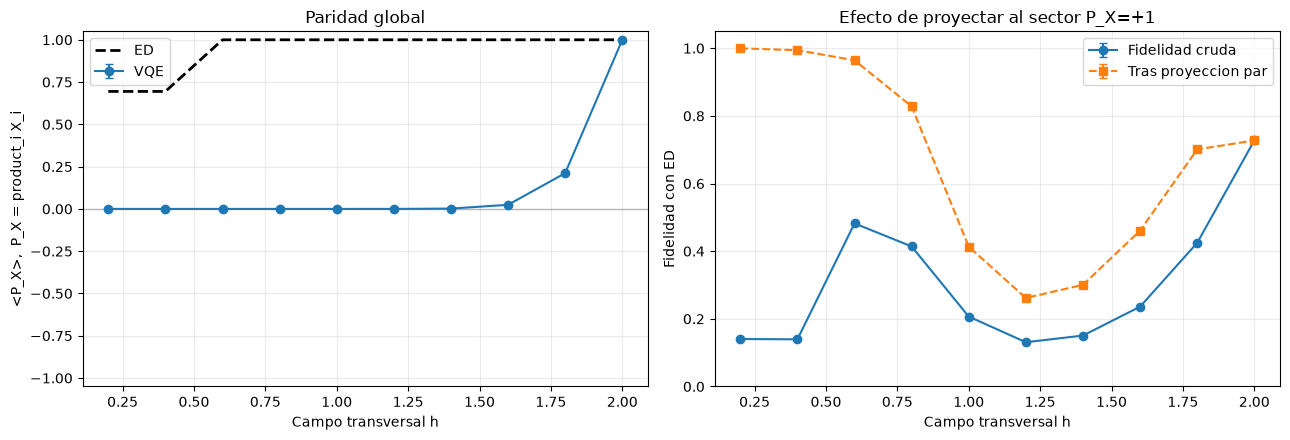

h    P_ED       P_VQE      p+_VQE     p+_ED     F_raw     F_raw_evenED  F_even_proj
0.2   0.694645  -0.000000   0.500000   0.847322   0.140279   0.499841   0.999682
0.4   0.694645   0.000006   0.500003   0.847322   0.139524   0.497145   0.994285
0.6   1.000000  -0.000010   0.499995   1.000000   0.482164   0.482164   0.964337
0.8   1.000000   0.000000   0.500000   1.000000   0.414087   0.414087   0.828174
1.0   1.000000   0.000001   0.500001   1.000000   0.206687   0.206687   0.413373
1.2   1.000000   0.000099   0.500050   1.000000   0.130852   0.130852   0.261677
1.4   1.000000   0.001931   0.500965   1.000000   0.150587   0.150587   0.300594
1.6   1.000000   0.024324   0.512162   1.000000   0.236018   0.236018   0.460827
1.8   1.000000   0.211571   0.605785   1.000000   0.424626   0.424626   0.700952
2.0   1.000000   0.999989   0.999995   1.000000   0.727335   0.727335   0.727339


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].errorbar(fields, parity_vqe_mean, yerr=parity_vqe_std, fmt='o-', capsize=3, label='VQE')
axes[0].plot(fields, parity_ed, 'k--', linewidth=2, label='ED')
axes[0].axhline(0.0, color='gray', linewidth=1, alpha=0.5)
axes[0].set_xlabel('Campo transversal h')
axes[0].set_ylabel(r'<P_X>,  P_X = product_i X_i')
axes[0].set_title('Paridad global')
axes[0].set_ylim(-1.05, 1.05)
axes[0].grid(alpha=0.25)
axes[0].legend()
axes[1].errorbar(fields, fidelity_mean, yerr=fidelity_std, fmt='o-', capsize=3, label='Fidelidad cruda')
axes[1].errorbar(fields, projected_fidelity_mean, yerr=projected_fidelity_std, fmt='s--', capsize=3, label='Tras proyeccion par')
axes[1].set_xlabel('Campo transversal h')
axes[1].set_ylabel('Fidelidad con ED')
axes[1].set_title('Efecto de proyectar al sector P_X=+1')
axes[1].set_ylim(0, 1.05)
axes[1].grid(alpha=0.25)
axes[1].legend()
fig.tight_layout()
fig.savefig(RESULTS_DIR / 'vqe_parity_and_projected_fidelity_adam500_later150_lbfgs80.png', dpi=180)
plt.show()

print('h    P_ED       P_VQE      p+_VQE     p+_ED     F_raw     F_raw_evenED  F_even_proj')
for index, field in enumerate(fields):
    print(f'{field:3.1f}  {parity_ed[index]: .6f}  {parity_vqe_mean[index]: .6f}  {parity_plus_weight_mean[index]: .6f}  {ed_even_weight_mean[index]: .6f}  {fidelity_mean[index]: .6f}  {fidelity_even_ed_mean[index]: .6f}  {projected_fidelity_mean[index]: .6f}')

## Comprobaciones finales

In [8]:
reported_error = np.asarray([abs(row['vqe_energy_reported'] - row['vqe_energy_reconstructed']) for row in analysis_rows])
print(f'Máximo desacuerdo energía reportada/reconstruida: {reported_error.max():.3e}')
print(f"Fidelidad mínima: {min(row['fidelity_with_ed'] for row in analysis_rows):.6f}")
print(f"Fidelidad máxima: {max(row['fidelity_with_ed'] for row in analysis_rows):.6f}")
print(f'Error absoluto medio de energía frente a ED: {energy_error_mean.mean():.6e}')
assert len(analysis_rows) == 30
assert reported_error.max() < 1e-4
assert all(0.0 <= row['fidelity_with_ed'] <= 1.000001 for row in analysis_rows)
print('Análisis validado.')

Máximo desacuerdo energía reportada/reconstruida: 7.248e-05
Fidelidad mínima: 0.130836
Fidelidad máxima: 0.727335
Error absoluto medio de energía frente a ED: 1.186045e+00
Análisis validado.
